In [2]:
"""
importing libraries
"""
import json
import os
import subprocess
import itertools
from datetime import datetime
import pandas as pd
from pathlib import Path
import sys
import pickle as pl
import torch
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:
env = os.environ.copy()
env['MKL_SERVICE_FORCE_INTEL'] = '1'
env['MKL_THREADING_LAYER'] = 'GNU'
env['OMP_NUM_THREADS'] = '1'

In [4]:
def sample_bimodal_beta(n=5000, p=0.5, a=2, b=90):
    """
    Generate samples from a bimodal distribution on [0,1] using a mixture of two Beta distributions.

    With probability p:
        sample from Beta(a, b) → concentrated near 0
    Otherwise:
        sample from Beta(b, a) → concentrated near 1

    This creates a bimodal shape with peaks near 0 and 1.
    """
    xs = []
    for _ in range(n):
        if random.random() < p:
            xs.append(random.betavariate(a, b))
        else:
            xs.append(random.betavariate(b, a))
    return xs



def plot_bimodial_beta(n=6000, p=0.5, a=1, b=14):
    """
    Visualize samples from a bimodal Beta mixture distribution.

    - Generates samples using sample_bimodal_beta
    - Shows two plots:
        1) Strip (scatter) plot to visualize density along [0,1]
        2) Histogram to show the estimated distribution shape
    """

    # 1) Sample values from the bimodal Beta mixture
    x = sample_bimodal_beta(n=n, p=p, a=a, b=b)

    # 2) Create a strip plot (scatter along x-axis)
    # Add small vertical jitter so overlapping points become visible
    y = [(random.random() - 0.5) * 0.08 for _ in x]  # jitter in [-0.04, 0.04]

    plt.figure()
    plt.scatter(x, y, s=3, alpha=0.25)
    plt.yticks([])  # y-axis has no meaning here (just for visualization)
    plt.xlim(0, 1)
    plt.title("Random point plot (bimodal mixture on [0,1])")
    plt.xlabel("x")
    plt.show()

    # 3) Plot histogram to visualize density more clearly
    plt.figure()
    plt.hist(x, bins=80, density=True)  # density=True normalizes counts
    plt.xlim(0, 1)
    plt.title("Histogram (density)")
    plt.xlabel("x")
    plt.ylabel("density")
    plt.show()

In [5]:
def parse_proportion_from_filename(filename):
    """Extract proportion array from filename like 'ag_news_6e-06_[0.1, 0.3, 0.3, 0.3].json'"""
    match = re.search(r'[\[\(]\s*([0-9eE+\-.,\s]+)\s*[\]\)]', filename)
    if match:
        arr = [float(x) for x in match.group(1).split(",") if x.strip()]
        return arr
    return None


def load_experiment_data(dataset_name,interpolation_name,base_dir):
    """
    Load all experiment results with their proportions.
    
    Args:
        base_dir: Path to directory containing experiment folders
        
    Returns:
        list: List of dicts with keys 'proportions', 'alignment_matrix', 'labels', 'output_dir'
    """
    base_path = Path(base_dir)
    
    # Find all directories that match the pattern
    all_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith(dataset_name) and interpolation_name in d.name]
    
    print(f"Scanning {len(all_dirs)} directories...")
    
    proportion_arr = []
    for output_dir in all_dirs:
        # Try to parse proportions from directory name
        proportion = parse_proportion_from_filename(output_dir.name)
        proportion_arr.append(proportion)
    return proportion_arr

In [6]:
def generate_vectors(dataset_name, interpolation_name, base_dir, num_classes, no_of_examples):
    """
    Generate unique normalized proportion vectors.

    - Each vector sums to 1
    - Avoids duplicates
    - Avoids already existing vectors from dataset
    """

    # proportion_arr = load_experiment_data(dataset_name, interpolation_name, base_dir)
    seen = set()
    # seen = set(tuple(p) for p in proportion_arr if p is not None)

    vectors = []

    while len(vectors) < no_of_examples:
        
        # Sample raw values from bimodal beta
        v = sample_bimodal_beta(n=num_classes, p=0.5, a=1, b=14)

        # Normalize to sum to 1
        s = sum(v)
        v = tuple(round(x / s, 3) for x in v)

        # Fix rounding drift (important)
        diff = 1.0 - sum(v)
        v = list(v)
        v[0] = round(v[0] + diff, 3)
        v = tuple(v)

        # Validate
        if v in seen or min(v) < 0.01 or sum(v)!=1:
            continue

        seen.add(v)
        vectors.append(v)

    return vectors

In [7]:
def generate_range(num_classes, no_of_examples):
    """
    Generate proportions with uniform deviation distribution, excluding existing ones
    
    Args:
        dataset_name: Dataset name for loading existing proportions
        interpolation_name: Interpolation method name
        base_dir: Base directory containing experiment results
        num_classes: Number of classes
        no_of_examples: Number of proportion vectors to generate
        num_bins: Number of deviation bins for uniform distribution (default: 10)
    
    Returns:
        List of proportion tuples with uniform deviation distribution
    """
    
    balanced = 1.0 / num_classes
    
    # Phase 1: Learn deviation range (generate 50 samples)
    learning_samples = []
    
    while len(learning_samples) < no_of_examples:
        v = [round(sample_bimodal_beta(n=1, p=0.5, a=1, b=14)[0], 2) for _ in range(num_classes)]
        sum_v = sum(v)
        v = [round(i/sum_v, 2) for i in v]
        v = tuple(v)
        
        if sum(v) == 1.0 and min(v) > 0.01:
            dev = np.mean([abs(x - balanced) for x in v])
            learning_samples.append((v, dev))
            
    deviations = [d for _, d in learning_samples]
    dev_min, dev_max = min(deviations), max(deviations)
    
    return dev_min, dev_max 

In [8]:
def balance_vectors_by_deviation(vectors, dev_min, dev_max, num_bins, num_classes, target_count):
    """
    Balance a set of probability vectors across deviation bins.

    Each vector is assigned a deviation score measuring how far it is from
    a perfectly balanced distribution (1 / num_classes per entry). The
    deviation range [dev_min, dev_max] is split into `num_bins`, and vectors
    are grouped accordingly.

    The function enforces:
    - Every bin must contain at least one vector (strict coverage)
    - Sampling is approximately uniform across bins
    - Final output size is exactly `target_count`

    Args:
        vectors (list): List of probability vectors (each sums to 1)
        dev_min (float): Minimum deviation bound
        dev_max (float): Maximum deviation bound
        num_bins (int): Number of bins over deviation range
        num_classes (int): Number of classes per vector
        target_count (int): Number of vectors to return

    Returns:
        list: Shuffled list of sampled vectors

    Raises:
        ValueError:
            - If target_count < num_bins
            - If any bin is empty (incomplete coverage)
    """

    # Ensure we can allocate at least one sample per bin
    if target_count < num_bins:
        raise ValueError("target_count must be at least num_bins")

    # Ideal uniform probability for each class
    balanced_val = 1.0 / num_classes

    # Mean absolute deviation from uniform distribution
    compute_dev = lambda v: np.mean(np.abs(np.array(v) - balanced_val))

    # Create equally spaced bins over deviation range
    bins = np.linspace(dev_min, dev_max, num_bins + 1)

    # Initialize buckets for each bin
    buckets = [[] for _ in range(num_bins)]

    # Assign each vector to its corresponding bin
    for v in vectors:
        idx = min(np.searchsorted(bins[1:], compute_dev(v)), num_bins - 1)
        buckets[idx].append(v)

    # Enforce strict coverage: no bin should be empty
    for i, bucket in enumerate(buckets):
        if not bucket:
            raise ValueError(f"Bin {i} is empty — deviation range not fully covered")

    # Compute how many samples to take per bin
    per_bin, rem = divmod(target_count, num_bins)

    sampled = []

    for i, bucket in enumerate(buckets):
        # Distribute remainder across first few bins
        k = per_bin + (i < rem)

        # Sample without replacement if possible, else with replacement
        sampled.extend(
            random.sample(bucket, k) if len(bucket) >= k else random.choices(bucket, k=k)
        )

    # Shuffle to remove bin-wise ordering bias
    random.shuffle(sampled)

    return sampled

In [9]:
def distance_of_proportions(X, no_of_classes, ddof=0):
    """
    X: array shape (N,no_of_classes) with values in [0,1]
    
    returns:
    P: normalized proportions, shape (N,no_of_classes)
    """
    X = np.asarray(X, dtype=float)
    l1 = np.mean(np.abs(X - float(1/no_of_classes)), axis=1)
    return l1

In [10]:
"""
Configuration
"""
num_classes = 10
dataset_name = 'yahoo_answers'
model = "gpt2"
base_dir =  f"./results_align_matrix/{model}/{dataset_name}"
interpolation = "linear"
num_bins = 25
num_vectors = 50

In [11]:
"""
Calling the functions
"""
min_dev, max_dev = generate_range(num_classes, 10000)

In [22]:
sample_vectors = generate_vectors(dataset_name,interpolation , base_dir, num_classes,200000)
vectors_list = balance_vectors_by_deviation(sample_vectors , min_dev, max_dev, num_bins, num_classes,num_vectors)

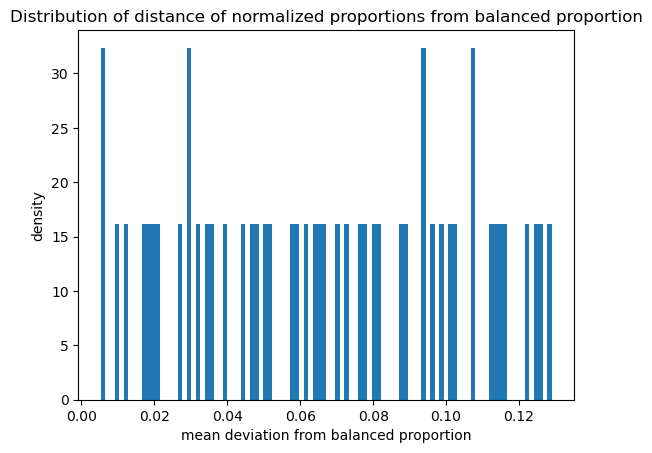

In [23]:
"""
Plotting the distance of normalized proportion
"""
l1 = distance_of_proportions(vectors_list, num_classes, ddof=0)
plt.figure()
plt.hist(l1, bins=100, density=True)  # density=True => area under histogram = 1
plt.xlabel("mean deviation from balanced proportion")
plt.ylabel("density")
plt.title("Distribution of distance of normalized proportions from balanced proportion")
plt.show()

### Running the experiments

In [24]:
# results_datainfo_path = Path("./results_datainfo/gpt2/ag_news")
# directories = [d for d in results_datainfo_path.iterdir() if d.is_dir()]

# vectors_list = []
# # Aggregate accuracy data across all experiments
# for path in directories:
#     files = [str(d.name) for d in Path(path).iterdir()]
#     if("converged_model.pt" in files):
#         match = re.search(r'\(([\d., ]+)\)', path.name)
#         vectors_list.append(tuple([float(x) for x in match.group(1).split(',')]))


In [25]:
# vectors_list = vectors_list[1:]

In [26]:
# len(vectors_list)

In [27]:
# for vector in vectors_list:
#     path = f"results_datainfo/gpt2/ag_news/ag_news_{vector}"
#     converged_model_path = os.path.join(path, 'converged_model') 
#     Path(converged_model_path).mkdir(parents=True, exist_ok=True)

    # converged_model_state_dict = torch.load(f"{path}/converged_model.pt", weights_only=False)

    # converged_model.load_state_dict(converged_model_state_dict)
    # converged_model.save_pretrained(overtrained_model_path)

In [28]:
parameter_grid = {
    "n_total": [5000],
    "n_finetune": [2500],
    "model_name": ["bert-base-uncased"],
    "max_length": [256],
    "num_labels": [10],
    "batch_size": [32],
    "learning_rate": [0.00002,0.00001,0.000006,0.000003],
    "num_epochs": [9],
    "K": [15],
    "lambda_min": [0.05],
    "lambda_max": [0.95],
    "interpolations": [[]],
    "optimizer": ["Adam"],
    "dataset": ["yahoo_answers"],
    "proportionArr": [vectors_list[0]],
    "finetuning_source": ["original"]
}

# parameter_grid = {
#     "n_total": [5000],
#     "n_finetune": [2500],
#     "model_name": ["gpt2"],
#     "max_length": [256],
#     "num_labels": [4],
#     "batch_size": [32],
#     "K": [15],
#     "lambda_min": [0.05],
#     "lambda_max": [0.95],
#     "dataset": ["ag_news"],
#     "proportionArr": vectors_list
# }

# parameter_grid = {
#     "n_total": [5000],
#     "n_finetune": [2500],
#     "model_name": ["gpt2"],
#     "max_length": [256,512],
#     "num_labels": [5],
#     "batch_size": [32],
#     "learning_rate": [0.0002],
#     "num_epochs": [9],
#     "K": [15],
#     "lambda_min": [0.05],
#     "lambda_max": [0.95],
#     "interpolations": [[]],
#     "optimizer": ["Adam"],
#     "dataset": ["yelp_review"],
#     "proportionArr": [vectors_list[:2]],
#     "finetuning_source": ["original"]
# }

# parameter_grid = {
#     "n_total": [5000],
#     "n_finetune": [2500],
#     "model_name": ["gpt2"],
#     "max_length": [256],
#     "num_labels": [4],
#     "batch_size": [32],
#     "learning_rate": [0.00003,0.00001],
#     "num_epochs": [9],
#     "K": [15],
#     "lambda_min": [0.05],
#     "lambda_max": [0.95],
#     "interpolations": [[]],
#     "optimizer": ["Adam"],
#     "dataset": ["ag_news"],
#     "proportionArr": [vectors_list[:2]],
#     "finetuning_source": ["original"]
# }

# bert-base-uncased


In [29]:
# Or define specific combinations
specific_configs = []

In [30]:
def generate_all_combinations(param_grid):
    """
    Generate all possible combinations of parameters from a grid.

    param_grid: dict
        Keys are parameter names, values are lists of possible values.

    Returns:
        List of dictionaries, where each dictionary represents
        one unique combination of parameters.
    """
    keys = param_grid.keys()
    values = param_grid.values()
    combinations = []
    
    for combination in itertools.product(*values):
        config = dict(zip(keys, combination))
        combinations.append(config)
    
    return combinations

def create_config_file(config, experiment_path):
    """
    Create and save a configuration file for an experiment in JSON format.

    config: dict
        Dictionary containing experiment parameters.

    experiment_path: str
        Base path/name for the experiment. This is also stored in the config
        and used to name the JSON file.
    """
    config['experiment_name'] = experiment_path
    config_path = experiment_path + ".json"
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print(f"Created config file: {config_path}")

def run_experiment(config, experiment_name):
    try:
        # Create config file
        create_config_file(config, f"{experiment_name}")
        
        print(f"\nRunning experiment: {experiment_name}")
        print(f"Config: {config}")
        
        if(config["model_name"]=="bert-base-uncased"):
            result = subprocess.call([sys.executable, "bert/bert_domain_distribution.py", f"{experiment_name}.json"],env=env)
        elif (config["model_name"]=="gpt2"):
            result = subprocess.call([sys.executable, "gpt2/gpt2_domain_distribution.py", f"{experiment_name}.json"],env=env)

        
        if result == 0:
            print(f"✅ Experiment {experiment_name} completed successfully")
        else:
            print(f"❌ Experiment {experiment_name} failed")
            # print("Error:", result.stderr)
        
        return {
            "experiment_name": experiment_name,
            "config": config,
            "success": result == 0,
        }
        
    except Exception as e:
        print(f"❌ Exception in {experiment_name}: {str(e)}")
        return {
            "experiment_name": experiment_name,
            "config": config,
            "success": False,
            "error": str(e)
        }

In [31]:
configs_to_run = generate_all_combinations(parameter_grid)
len(configs_to_run)

4

In [ ]:
# Choose experiment mode
USE_GRID_SEARCH = True # Set to True for grid search, False for specific configs

if USE_GRID_SEARCH:
    configs_to_run = generate_all_combinations(parameter_grid)
    print(f"Total configurations to run: {len(configs_to_run)}")
    
    # for i in range(len(configs_to_run)):
    #     json_output = configs_to_run[i]
    #     json_output['proportionArr'] = json_output['proportionArr'][i%len(configs_to_run)]
    
    print(configs_to_run)

    # Run all experiments
    results = []
    for i, config in enumerate(configs_to_run):
        experiment_name = f"{config['dataset']}_{config['proportionArr']}"
        result = run_experiment(config, experiment_name)
        results.append(result)

    # Summary
    successful = sum(1 for r in results if r["success"])
    print(f"\n{'='*50}")
    print(f"EXPERIMENT SUMMARY")
    print(f"{'='*50}")
    print(f"Total experiments: {len(results)}")
    print(f"Successful: {successful}")
    print(f"Failed: {len(results) - successful}")
        
else:
    configs_to_run = specific_configs

Total configurations to run: 4
[{'n_total': 5000, 'n_finetune': 2500, 'model_name': 'bert-base-uncased', 'max_length': 256, 'num_labels': 10, 'batch_size': 32, 'learning_rate': 2e-05, 'num_epochs': 9, 'K': 15, 'lambda_min': 0.05, 'lambda_max': 0.95, 'interpolations': [], 'optimizer': 'Adam', 'dataset': 'yahoo_answers', 'proportionArr': (0.107, 0.108, 0.095, 0.012, 0.112, 0.113, 0.116, 0.115, 0.11, 0.112), 'finetuning_source': 'original'}, {'n_total': 5000, 'n_finetune': 2500, 'model_name': 'bert-base-uncased', 'max_length': 256, 'num_labels': 10, 'batch_size': 32, 'learning_rate': 1e-05, 'num_epochs': 9, 'K': 15, 'lambda_min': 0.05, 'lambda_max': 0.95, 'interpolations': [], 'optimizer': 'Adam', 'dataset': 'yahoo_answers', 'proportionArr': (0.107, 0.108, 0.095, 0.012, 0.112, 0.113, 0.116, 0.115, 0.11, 0.112), 'finetuning_source': 'original'}, {'n_total': 5000, 'n_finetune': 2500, 'model_name': 'bert-base-uncased', 'max_length': 256, 'num_labels': 10, 'batch_size': 32, 'learning_rate': 6

2026-05-03 05:48:07.867395: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-03 05:48:07.885086: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-03 05:48:07.885103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-03 05:48:07.885680: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-03 05:48:07.888647: I tensorflow/core/platform/cpu_feature_guar

✓ Mergekit imported successfully
Loading configuration from: yahoo_answers_(0.107, 0.108, 0.095, 0.012, 0.112, 0.113, 0.116, 0.115, 0.11, 0.112).json
✓ Configuration loaded successfully

Output directory created: yahoo_answers_(0.107, 0.108, 0.095, 0.012, 0.112, 0.113, 0.116, 0.115, 0.11, 0.112)

Full training set size: 1286121
Selected subset D with 5000 samples
Label idx: 0
267
Label idx: 1
270
Label idx: 2
237
Label idx: 3
30
Label idx: 4
280
Label idx: 5
282
Label idx: 6
290
Label idx: 7
287
Label idx: 8
275
Label idx: 9
280
Size of the computed finetuning set: 2498 

✓ Dataset info saved to yahoo_answers_(0.107, 0.108, 0.095, 0.012, 0.112, 0.113, 0.116, 0.115, 0.11, 0.112)/dataset_info.json

STEP 3: Fine-tuning on D' to Create Expert Model (θ_exp)
Fine-tuning configuration:
  Learning rate: 2e-05
  Batch size: 32
  Epochs: 9
  Training samples: 2500
  Batches per epoch: 79
Batch Interval: 44


/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Epoch 1/9:  54%|█████▍    | 43/79 [00:14<00:11,  3.22it/s, loss=1.99]

In [ ]:
# When a parent process starts a child process via subprocess, the two are separate entities with their own memory space.
# The parent process is not notified in real-time about the filesystem modifications the child process is making.

In [ ]:
# is the leanrign rate too big or the avriation is cause of the different eval data sample. by testing it with a fixed sample, we saw marginal improvement..so it was cause of variation of the val data and the learnignrate was too small
# the leanrign rate for good elanrign has to be around 6*10-5..
# lets see of its the same for bert..bert is knwon to stablissie around 6*10-6 as per my experiments...this elanrignr ate is rpoved for a dixed eval set

# lets see for a variable eval set

# gpt: 6*10-5
# bert: 3*10-5 , we are doign 6*10-5

In [ ]:
# from datasets import load_dataset
# dataset = load_dataset('yelp/yelp_review_full')

In [ ]:
# Increasing batch size reduces gradient noise, which allows for larger learning rates up to a point. 
# However, beyond that, the step size is limited by the curvature of the loss landscape, not gradient stability, so linear scaling breaks down.

In [ ]:
# Basically, the core point is that if you open the same folder in multiple windows,
# any action in one (like git checkout) is reflected in all of them. If you instead
# clone the repo multiple times, each clone has its own separate .git, and merging
# local branches would require syncing through GitHub, which becomes complex and defeats
# the purpose of working locally. Worktrees solve this by allowing you to work on multiple
# local branches simultaneously in different folders, all sharing a single .git repository.

In [ ]:
# we want the no of epochs , learning rate and batch size to be the same 
# since we work with different models, the learnign rate needs to be changed but thankfully, we have a leanrignr ate that works with ebrt and gpt 
# at the same time, during training , since the effect of a greater learning rate on bert causes too much leanring in one epoch, we can implemnent gradient clipping so that 
# loss divergence does not happen later in the training trajectory.

In [ ]:
# our mean divergence as a criteria cannot be used across classes since the no of classes changes / enforces 
# a constraint that one partcualr class can have, cause the sum has to be 1..so the mean deviation is lesser as
# the no of classes icnrease.

In [ ]:
import os
from pathlib import Path

all_dirs = [str(d) for d in Path('.').iterdir() if d.is_dir()]
converged_dirs = ["ag_news_(" in dir for dir in all_dirs]
final_dirs = []

for index in range(len(converged_dirs)):
    if(converged_dirs[index]):
        final_dirs.append(all_dirs[index])

In [ ]:
final_dirs

In [ ]:
accuracy_arrays = []
for dir in final_dirs:
    
    try:
        with open("./" + dir + "/accuracy_arr.pkl",'rb') as f:
            last_accuracy = pl.load(f)[-1]
            accuracy_arrays.append(last_accuracy)
            
    except:
        pass

plt.figure(figsize=(10, 6))
plt.hist(accuracy_arrays, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlim(0, 1) 
plt.xlabel("Value", fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontsize=12, fontweight='bold')
plt.title("acc array", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import pickle as pl

In [ ]:
path = "/home/aditya/hack_model/yelp_review_(0.08, 0.023, 0.817, 0.04, 0.04)"

In [ ]:
with open( path + '/accuracy_arr.pkl','rb') as f:
    df = pl.load(f)

In [ ]:
df

In [ ]:
with open( path + '/accuracy_arr_converged.pkl','rb') as f:
    df = pl.load(f)

In [ ]:
df

In [ ]:
with open( path + '/accuracy_arr_overtrained.pkl','rb') as f:
    df = pl.load(f)

In [ ]:
df

In [ ]:
with open( path + '/loss_arr_overtrained.pkl','rb') as f:
    df = pl.load(f)

In [ ]:
df 